<a href="https://colab.research.google.com/github/NaydelinAidee/Procesos-Estocasticos/blob/main/Actividad5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad 5**

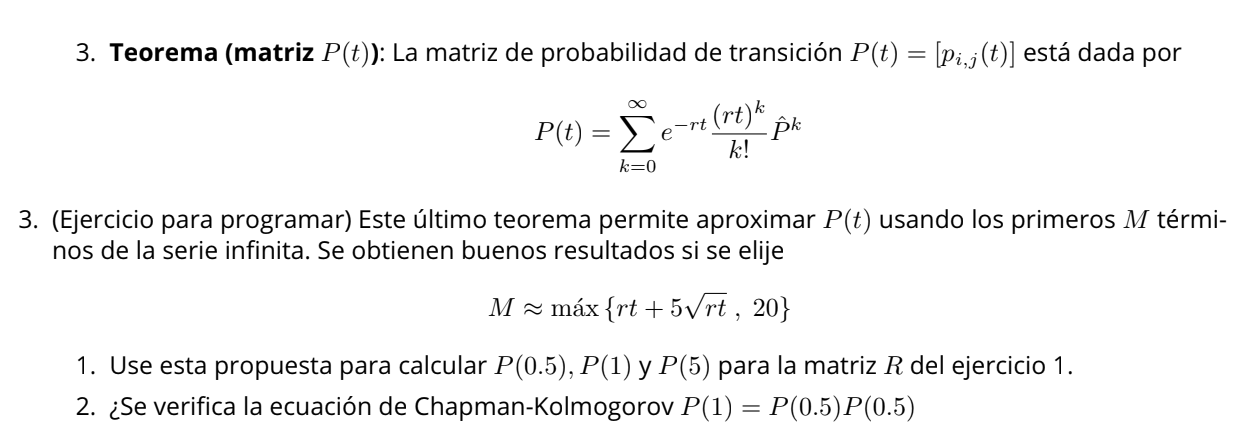

Primero vamos a transformar la matriz de tasas de transición dada  en una Matriz Generadora de Tasas (matriz $R$) válida para un modelo de Cadenas de Markov de Tiempo Continuo. Esta matriz es fundamental para aplicar el Teorema de Uniformización y calcular las probabilidades de transición en un tiempo $t$, denotadas como $P(t)$.

En un proceso estocástico de tiempo continuo, los valores fuera de la diagonal principal ($R_{ij}$ para $i \neq j$) representan la tasa a la cual el sistema transita del estado $i$ al estado $j$. Sin embargo, la matriz generadora de tasas requiere cumplir con la propiedad fundamental de conservación de la probabilidad. Esto implica que la suma de las tasas de cada renglón debe ser exactamente igual a cero:

\begin{equation*}
\sum_{j} R_{ij} = 0 \quad \text{para toda } i
\end{equation*}

Para cumplir con esta condición, el valor en la diagonal principal ($R_{ii}$) debe ser igual a la suma de todas las tasas de salida de ese estado, pero con signo negativo. Es decir, $R_{ii}$ representa la tasa total a la que el sistema abandona el estado $i$:

\begin{equation*}
R_{ii} = - \sum_{j \neq i} R_{ij}
\end{equation*}

Dada la matriz inicial con tasas de transición:
\begin{equation*}
R_{\text{inicial}} = \begin{pmatrix}
0 & 2 & 3 & 0 \\
4 & 0 & 2 & 0 \\
0 & 2 & 0 & 2 \\
1 & 0 & 3 & 0
\end{pmatrix}
\end{equation*}

Se procedió a calcular los valores de la diagonal ($R_{11}, R_{22}, R_{33}, R_{44}$) sumando los elementos restantes de cada renglón y multiplicando el resultado por $-1$:

Renglón 1:
* $R_{11} = -(2 + 3 + 0) = -5$
* $R_{22} = -(4 + 2 + 0) = -6$
* $R_{33} = -(0 + 2 + 2) = -4$
* $R_{44} = -(1 + 0 + 3) = -4$


La matriz generadora $R$ ajustada y lista para ser implementada en el algoritmo de uniformización es:
\begin{equation*}
R = \begin{pmatrix}
-5 & 2 & 3 & 0 \\
4 & -6 & 2 & 0 \\
0 & 2 & -4 & 2 \\
1 & 0 & 3 & -4
\end{pmatrix}
\end{equation*}


Definimos nuestras librerias y definimos la matriz que ya obtuvimos

In [6]:
import numpy as np
import math

# Definimos la matriz R corregida (la suma de cada renglón es 0)
R = np.array([
    [-5.0,  2.0,  3.0,  0.0],
    [ 4.0, -6.0,  2.0,  0.0],
    [ 0.0,  2.0, -4.0,  2.0],
    [ 1.0,  0.0,  3.0, -4.0]
])

Dentro de nuestra función, lo primero es encontrar la "tasa de uniformización" (r). Esta es el valor absoluto más grande de la diagonal. Con r, podemos calcular la matriz estocástica embebida (
$\hat{P}$).

In [7]:
def aproximar_Pt(R, t):
    # Extraemos la diagonal, aplicamos valor absoluto y sacamos el máximo (r=6 en este caso)
    r = np.max(np.abs(np.diagonal(R)))
    #Creamos la matriz Identidad
    I = np.eye(R.shape[0])
    #Calculamos Pgorro con la fórmula del teorema
    P_gorro = I + (1/r) * R
    rt = r * t
    # Calculamos el límite M.
    M = int(np.ceil(max(rt + 5 * math.sqrt(rt), 20)))
        #matriz de puros ceros,aquí iremos acumulando la suma.
    P_t = np.zeros_like(R, dtype=float)
    #Preparamos P_gorro elevada a la k. Para k=0, la matriz es la Identidad.
    P_gorro_k = I.copy()
    #Calculamos  Poisson para k=0.
    p_k = math.exp(-rt)
    #range(M + 1) cuenta desde 0 hasta M.
    for k in range(M + 1):

        # Si k es mayor a 0, actualizamos nuestros multiplicadores iterativamente
        if k > 0:
            p_k = p_k * (rt / k)
            P_gorro_k = np.dot(P_gorro_k, P_gorro) # Multiplicación de matrices

        # Multiplicamos el escalar p_k por la matriz P_gorro_k y lo sumamos al total
        P_t += p_k * P_gorro_k

    return P_t, M


In [8]:
P_05, M_05 = aproximar_Pt(R, 0.5)
print(f"\n1. P(0.5) calculado usando M={M_05} términos:")
print(np.round(P_05, 5))

P_1, M_1 = aproximar_Pt(R, 1.0)
print(f"\n2. P(1) calculado usando M={M_1} términos:")
print(np.round(P_1, 5))

P_5, M_5 = aproximar_Pt(R, 5.0)
print(f"\n3. P(5) calculado usando M={M_5} términos:")
print(np.round(P_5, 5))


1. P(0.5) calculado usando M=20 términos:
[[0.25061 0.21696 0.38666 0.14577]
 [0.25313 0.23836 0.37441 0.13409]
 [0.16912 0.19361 0.4203  0.21696]
 [0.15802 0.15744 0.39833 0.28621]]

2. P(1) calculado usando M=20 términos:
[[0.20615 0.2039  0.39871 0.19124]
 [0.20828 0.20534 0.3979  0.18847]
 [0.19676 0.19838 0.40096 0.2039 ]
 [0.19205 0.194   0.40147 0.21248]]

3. P(5) calculado usando M=58 términos:
[[0.2 0.2 0.4 0.2]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.4 0.2]]


Verificación de Chapman-Kolmogorov

En esta segunda parte del ejercicio, el objetivo principal es realizar una validación empírica de una de las propiedades más importantes de los procesos estocásticos y las Cadenas de Markov: la ecuación de Chapman-Kolmogorov. Esta propiedad establece el principio de que la probabilidad de transitar de un estado a otro en un intervalo de tiempo total ($t+s$) es equivalente a realizar la transición en dos pasos sucesivos a través de cualquier estado intermedio, lo cual matricialmente se traduce en la multiplicación de las matrices de probabilidad de los subintervalos ($t$ y $s$).

Buscamos demostrar que la matriz obtenida directamente para el tiempo $t=1$ es equivalente al producto matricial de la evaluación en $t=0.5$ multiplicada por sí misma; es decir:
\begin{equation*}
P(1) \approx P(0.5) \cdot P(0.5)
\end{equation*}


In [9]:
print("\n VERIFICACIÓN DE CHAPMAN-KOLMOGOROV ")
# Multiplicamos la matriz P(0.5) por sí misma.
P_05_por_P_05 = np.dot(P_05, P_05)
print("Matriz resultante de P(0.5) * P(0.5):")
print(np.round(P_05_por_P_05, 5))
print("\nMatriz P(1) calculada en el inciso anterior:")
print(np.round(P_1, 5))
#  Verificamos si ambas matrices  iguales.
son_iguales = np.allclose(P_1, P_05_por_P_05, atol=1e-5)
print(f"\n¿Se verifica la ecuación P(1) = P(0.5)P(0.5)? : {'SÍ' if son_iguales else 'NO'}")


 VERIFICACIÓN DE CHAPMAN-KOLMOGOROV 
Matriz resultante de P(0.5) * P(0.5):
[[0.20615 0.2039  0.39871 0.19124]
 [0.20828 0.20534 0.3979  0.18847]
 [0.19676 0.19838 0.40096 0.2039 ]
 [0.19205 0.194   0.40147 0.21248]]

Matriz P(1) calculada en el inciso anterior:
[[0.20615 0.2039  0.39871 0.19124]
 [0.20828 0.20534 0.3979  0.18847]
 [0.19676 0.19838 0.40096 0.2039 ]
 [0.19205 0.194   0.40147 0.21248]]

¿Se verifica la ecuación P(1) = P(0.5)P(0.5)? : SÍ


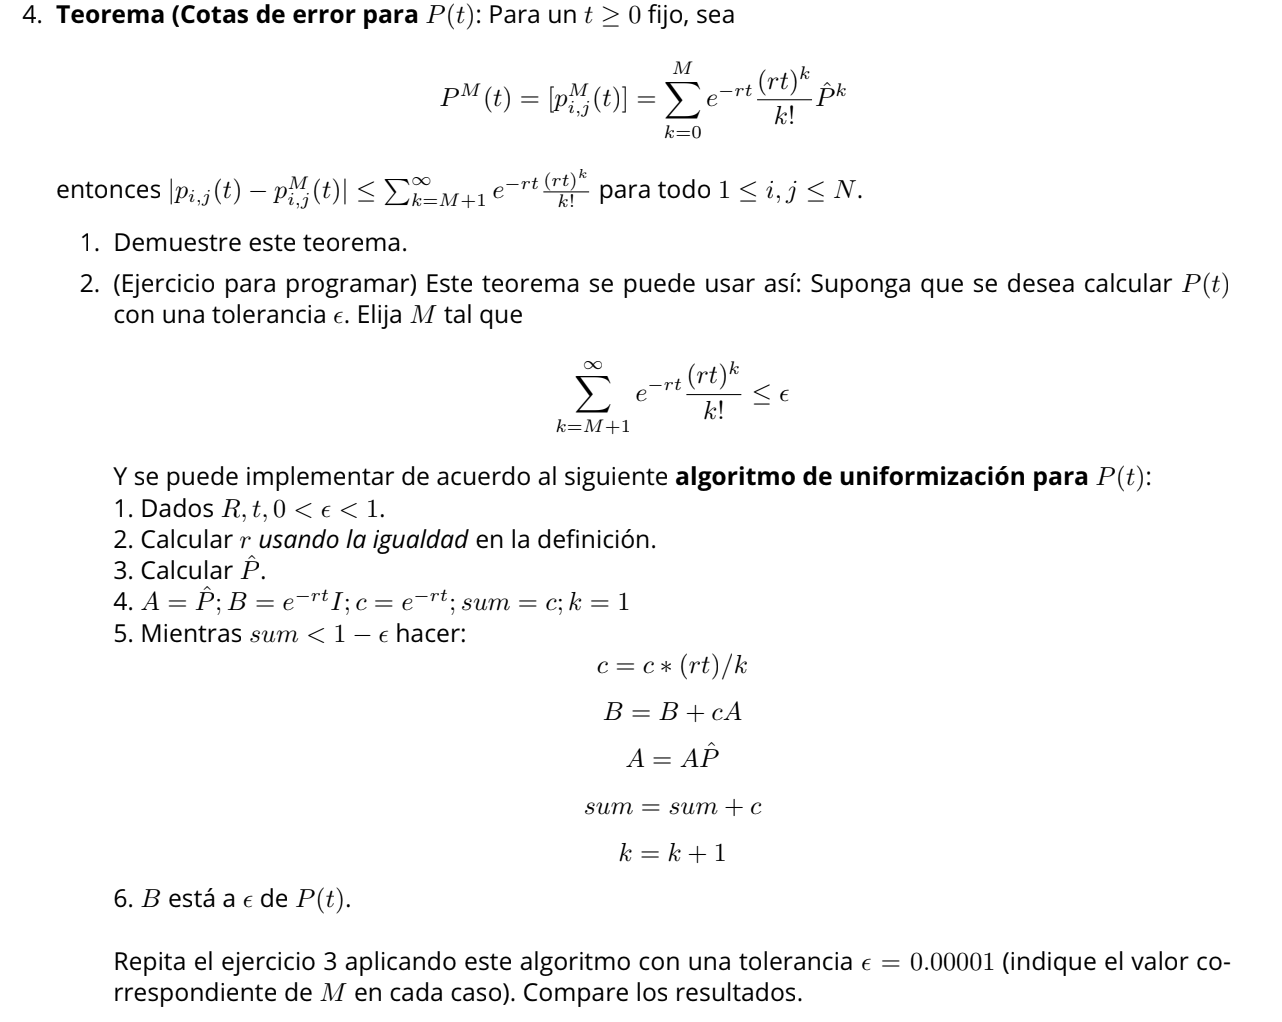

Aquí sacamos nuestra tasa máxima de uniformización (r), calculamos la matriz base con la que vamos a trabajar $\hat{P}$ y preparamos las variables con los valores iniciales para cuando k=0.

Usamos un ciclo while  que dice: "Sigue sumando términos mientras la probabilidad que me falta para llegar a 1 sea mayor a mi error permitido". En cada vuelta del ciclo, actualizamos nuestra probabilidad, la multiplicamos por nuestra matriz, la guardamos en (B), y aumentamos k para el siguiente paso.

In [14]:
import numpy as np
import math

def aproximar_Pt_error(R, t, epsilon):
    #Sacamos r (el máximo valor de la diagonal) y calculamos P_gorro
    r = np.max(np.abs(np.diagonal(R)))
    I = np.eye(R.shape[0])
    P_gorro = I + (1/r) * R
    rt = r * t
    #variables iniciales (para cuando k=0)
    A = P_gorro.copy()
    B = math.exp(-rt) * I       # aquí iremos sumando las matrices P(t)
    c = math.exp(-rt)           # c es nuestro número de probabilidad de Poisson
    suma = c                    # probabilidad  acumulada
    k = 1
    # frena en seco en cuanto el error (1 - suma) sea menor a epsilon
    while suma < 1 - epsilon:
        # fórmula de Poisson iterativa
        c = c * (rt) / k
        # Le sumamos este nuevo pedacito a nuestra matriz total
        B = B + (c * A)
        # Preparamos la matriz A para la siguiente vuelta (multiplicándola por sí misma)
        A = np.dot(A, P_gorro)
        # Actualizamos nuestro acumulador de probabilidad y pasamos a la siguiente k
        suma = suma + c
        k = k + 1

    #Cuando el ciclo acaba, restamos 1 a k (porque sumó 1 de más antes de salirse)
    M = k - 1
    return B, M

Por último, solo metemos los datos de nuestro problema real. Escribimos la matriz R correcta (la que tiene los negativos en la diagonal), definimos nuestro error ϵ y mandamos llamar a la función para los tres tiempos que nos pide la tarea (0.5, 1 y 5).

In [15]:
#Ponemos los datos de nuestra matriz
R = np.array([
    [-5.0,  2.0,  3.0,  0.0],
    [ 4.0, -6.0,  2.0,  0.0],
    [ 0.0,  2.0, -4.0,  2.0],
    [ 1.0,  0.0,  3.0, -4.0]
])

eps = 0.00001

print("RESULTADOS")

P_05, M_05 = aproximar_Pt_error(R, 0.5, eps)
print(f"\nP(0.5) calculado con error < {eps}: (Lo logró en M = {M_05} pasos)")
print(np.round(P_05, 5))

P_1, M_1 = aproximar_Pt_error(R, 1.0, eps)
print(f"\nP(1.0) calculado con error < {eps}: (Lo logró en M = {M_1} pasos)")
print(np.round(P_1, 5))

P_5, M_5 = aproximar_Pt_error(R, 5.0, eps)
print(f"\nP(5.0) calculado con error < {eps}: (Lo logró en M = {M_5} pasos)")
print(np.round(P_5, 5))

RESULTADOS

P(0.5) calculado con error < 1e-05: (Lo logró en M = 13 pasos)
[[0.25061 0.21696 0.38666 0.14577]
 [0.25313 0.23836 0.37441 0.13409]
 [0.16912 0.19361 0.4203  0.21696]
 [0.15802 0.15744 0.39833 0.28621]]

P(1.0) calculado con error < 1e-05: (Lo logró en M = 19 pasos)
[[0.20615 0.2039  0.39871 0.19124]
 [0.20828 0.20534 0.3979  0.18847]
 [0.19676 0.19838 0.40096 0.2039 ]
 [0.19205 0.194   0.40147 0.21248]]

P(5.0) calculado con error < 1e-05: (Lo logró en M = 56 pasos)
[[0.2 0.2 0.4 0.2]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.4 0.2]]
